In [14]:
# No external libraries needed — only Python built-ins
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


#Task 1 Implement RLE compression and decompression and apply it to a string of your choice

In [15]:
def rle_compress(text):
    compressed = []
    i = 0

    while i < len(text):
        current_char = text[i]
        count = 1

        while i + count < len(text) and text[i + count] == current_char:
            count += 1

        compressed.append((current_char, count))
        i += count

    return compressed

def rle_decompress(compressed):
    result = ""

    for char, count in compressed:
        for i in range(count):
            result += char

    return result

original = "AABBBCDDDDDDDEEFGGGG"
print("Original string :", original)

compressed_rle = rle_compress(original)
print("Compressed pairs:", compressed_rle)

decompressed_rle = rle_decompress(compressed_rle)
print("Decompressed    :", decompressed_rle)

if decompressed_rle == original:
    print("Matches original!")
else:
    print(" Something went wrong!")


Original string : AABBBCDDDDDDDEEFGGGG
Compressed pairs: [('A', 2), ('B', 3), ('C', 1), ('D', 7), ('E', 2), ('F', 1), ('G', 4)]
Decompressed    : AABBBCDDDDDDDEEFGGGG
Matches original!


# Task 2  Implement Huffman decompression and apply it to the following binary sequence, using the codes from Table 1, to retrieve the original sequence.

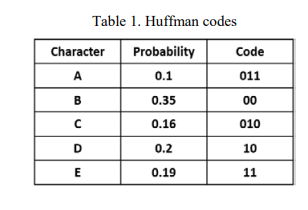


In [16]:
def huffman_decompress(binary, codes):
    result = ""
    buffer = ""   # accumulates bits until a match is found

    for bit in binary:
        buffer += bit

        # Check if buffer matches any code in our table
        if buffer in codes:
            result += codes[buffer]
            buffer = ""   # reset and start fresh

    return result

# Table 1 from the lab – key = binary code, value = character
huffman_codes = {}
huffman_codes['011'] = 'A'
huffman_codes['00']  = 'B'
huffman_codes['010'] = 'C'
huffman_codes['10']  = 'D'
huffman_codes['11']  = 'E'

# Binary sequence from the lab
binary_sequence = (
    "01100011010011000110010010010011100011110001011000111010111111000110111111110010111"
    "01011111100010001111100001000101000110100101100000111100010110100000010010000001000"
    "000100000011000000001010100000101000000101010001001010100000"
)

print("Binary length:", len(binary_sequence), "bits")

decoded = huffman_decompress(binary_sequence, huffman_codes)
print("Decoded string:", decoded)



Binary length: 226 bits
Decoded string: ABACABABDCCADBEEBCEBADDEEEBAAEEEBDEDDEEEBCBEEDBCBDDBECCEBBAEBCECBBCCBBCBBCBBABBBBDDDBBDDBBCDDBDCDDBB


# Task 3. Implement LZ compression and decompression. Use the resulting methods to compress and then decompress the string BAABABBBAABBBBAA. Display the resulting compressed sequence and dictionary, and verify that the decompressed sequence matches the original one.

In [17]:
def lz_compress(text):
    dictionary = {}
    next_index  = 1
    compressed  = []

    i = 0
    while i < len(text):

        current = ""
        last_found_index = 0

        j = i
        while j < len(text):
            current += text[j]
            found = False
            for idx, val in dictionary.items():
                if val == current:
                    last_found_index = idx
                    found = True
                    break

            if found:
                j += 1
            else:
                dictionary[next_index] = current
                next_index += 1

                if last_found_index == 0:
                    compressed.append(text[j])
                else:
                    compressed.append((last_found_index, text[j]))

                i = j + 1
                break

        else:
            compressed.append(last_found_index)
            i = j + 1

    return compressed, dictionary

def lz_decompress(compressed, dictionary):
    result = ""

    for token in compressed:
        if isinstance(token, str):
            # single new character
            result += token

        elif isinstance(token, tuple):
            # prefix_index + new_character
            idx, new_char = token
            result += dictionary[idx] + new_char

        elif isinstance(token, int):
            # end of the string case
            result += dictionary[token]

    return result



original_lz = "BAABABBBAABBBBAA"
print("Original:", original_lz)

compressed_lz, dictionary_lz = lz_compress(original_lz)

print("\nCompressed tokens:", compressed_lz)
print("\nDictionary built:")
for k, val in dictionary_lz.items():
    print(f"  {k} → {val}")


decompressed_lz = lz_decompress(compressed_lz, dictionary_lz)
print("Decompressed:", decompressed_lz)

if decompressed_lz == original_lz:
    print("Matches original!")
else:
    print("Something went wrong!")

Original: BAABABBBAABBBBAA

Compressed tokens: ['B', 'A', (2, 'B'), (3, 'B'), (1, 'A'), (4, 'B'), (5, 'A')]

Dictionary built:
  1 → B
  2 → A
  3 → AB
  4 → ABB
  5 → BA
  6 → ABBB
  7 → BAA
Decompressed: BAABABBBAABBBBAA
Matches original!


In [18]:
# RLE

original_size_rle   = len(original)
compressed_size_rle = len(compressed_rle) * 2
ratio_rle = original_size_rle / compressed_size_rle
print(f"RLE ratio: {original_size_rle} / {compressed_size_rle} = {ratio_rle:.2f}:1")

# Huffman

original_size_huff   = len(decoded) * 8
compressed_size_huff = len(binary_sequence)
ratio_huff = original_size_huff / compressed_size_huff
print(f"Huffman ratio: {original_size_huff} / {compressed_size_huff} = {ratio_huff:.2f}:1")


# LZ
original_size_lz   = len(original_lz)
compressed_size_lz = len(compressed_lz)

ratio_lz = original_size_lz / compressed_size_lz
print(f"LZ ratio: {original_size_lz} / {compressed_size_lz} = {ratio_lz:.2f}:1")

RLE ratio: 20 / 14 = 1.43:1
Huffman ratio: 800 / 226 = 3.54:1
LZ ratio: 16 / 7 = 2.29:1
